# Assignment 2: Sanskrit-to-English Neural Machine Translation (NMT)

## Course
Natural Language Understanding (NLU)

---

## Student Details

| Field | Details |
|--------|---------|
| Student Name | <Your Name> |
| Roll Number | <Your Roll Number> |
| Assignment | Assignment 2 |
| Framework | PyTorch |
| Architecture | Seq2Seq (LSTM + Attention + Beam Search) |

---

## Objective

Develop a custom Neural Machine Translation (NMT) model to translate Sanskrit sentences into English using a Sequence-to-Sequence (Seq2Seq) architecture with:

- LSTM Encoder
- Attention-based Decoder
- Beam Search Decoding

Evaluate the model using:

- BLEU Score
- BERTScore
- Inference Time
- Total Trainable Parameters

---

## Notebook Structure

1. Installation & Imports
2. Configuration (all tuneable parameters)
3. Data Loading & Preprocessing
4. Vocabulary
5. Dataset & DataLoader
6. Model (Encoder · Attention · Decoder · Seq2Seq)
7. Training
8. Inference (Greedy + Beam Search)
9. Evaluation (BLEU · BERTScore · Efficiency)
10. Submission CSV
11. Translation Examples & Error Analysis

---

## 1. Installation & Imports
### Install Required Packages

In [161]:
# ==========================================================
# INSTALL REQUIRED PACKAGES
# ==========================================================

# Deep Learning Framework
%pip install -q torch torchvision torchaudio

# Data Processing
%pip install -q pandas numpy

# Visualization
%pip install matplotlib

# NLP Utilities
%pip install -q nltk

# Evaluation Metric
%pip install -q bert-score

# Tokenizer (Optional but recommended)
%pip install -q sentencepiece

# Progress Bar
%pip install -q tqdm

print("All required packages installed successfully.")

All required packages installed successfully.


### Import Libraries

In [162]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [163]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

# ----------------------------
# Standard Library
# ----------------------------
import os
import re
import time
import math
import random
import warnings
from collections import Counter

# ----------------------------
# Data Processing
# ----------------------------
import numpy as np
import pandas as pd

# ----------------------------
# Visualization
# ----------------------------
import matplotlib.pyplot as plt

# ----------------------------
# Progress Bar
# ----------------------------
from tqdm.auto import tqdm

# ----------------------------
# Deep Learning (PyTorch)
# ----------------------------
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

# ----------------------------
# Evaluation
# ----------------------------
import nltk
from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bert_score

# ----------------------------
# Tokenizer
# ----------------------------
import sentencepiece as spm

warnings.filterwarnings("ignore")

### Download Required NLTK Resources

In [164]:
# ==========================================================
# DOWNLOAD NLTK RESOURCES
# ==========================================================

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### Verify Installation

In [165]:
# ==========================================================
# VERIFY ENVIRONMENT
# ==========================================================

print("=" * 60)
print("Environment Verification")
print("=" * 60)

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
else:
    print("GPU             : CPU Runtime")

print("=" * 60)

Environment Verification
PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU             : Tesla T4


## 2. Configuration
> **All dataset paths and hyperparameters are centralised here.**  
> To run on a new dataset, update `Dataset Paths` only.

In [294]:
# ==========================================================
# CONFIGURATION
# ==========================================================

DATASET_DIR = "/content/drive/MyDrive/NLU/content"

# Dataset Paths
TRAIN_SA = f"{DATASET_DIR}/train_sa_10000.csv"
TRAIN_EN = f"{DATASET_DIR}/train_en_10000.csv"

DEV_SA = f"{DATASET_DIR}/dev_sa_1000.csv"
DEV_EN = f"{DATASET_DIR}/dev_en_1000.csv"

TEST_SA = f"{DATASET_DIR}/test_sa_1000.csv"
TEST_EN = f"{DATASET_DIR}/test_en_1000.csv"

# Dataset Columns
ID_COL = "Source_id"
SOURCE_COL = "Sentence_sa"
TARGET_COL = "Sentence_en"

# Vocabulary
PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

MIN_FREQ = 2
MAX_LENGTH = 100

# Model
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.3

# Training
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 20

# Teacher Forcing
TEACHER_FORCING_RATIO = 0.5

# Inference
BEAM_WIDTH = 5

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
SEED = 42

***Set Random Seed***

In [167]:
# ==========================================================
# REPRODUCIBILITY
# ==========================================================

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 3. Data Loading & Preprocessing

> Step 1 — Load CSV Files

In [168]:
# ==========================================================
# LOAD DATASETS
# ==========================================================

train_sa = pd.read_csv(TRAIN_SA)
train_en = pd.read_csv(TRAIN_EN)

dev_sa = pd.read_csv(DEV_SA)
dev_en = pd.read_csv(DEV_EN)

test_sa = pd.read_csv(TEST_SA)
test_en = pd.read_csv(TEST_EN)

> Step 2 — Merge Parallel Corpora

In [169]:
# ==========================================================
# MERGE PARALLEL DATASETS
# ==========================================================

train_df = pd.merge(train_sa, train_en, on=ID_COL)

dev_df = pd.merge(dev_sa, dev_en, on=ID_COL)

test_df = pd.merge(test_sa, test_en, on=ID_COL)

> Step 3 — Verify Dataset

In [170]:
# ==========================================================
# DATASET INFORMATION
# ==========================================================

print("Training :", train_df.shape)
print("Validation :", dev_df.shape)
print("Testing :", test_df.shape)

train_df.head()

Training : (10000, 3)
Validation : (1000, 3)
Testing : (1000, 3)


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


> Step 4 — Text Cleaning Function

In [171]:
# ==========================================================
# TEXT CLEANING
# ==========================================================

def clean_text(text):

    text = str(text)

    text = text.strip()

    text = " ".join(text.split())

    return text

> Step 5 — Apply Cleaning

In [172]:
# ==========================================================
# PREPROCESS DATA
# ==========================================================

for df in [train_df, dev_df, test_df]:

    df[SOURCE_COL] = df[SOURCE_COL].apply(clean_text)

    df[TARGET_COL] = df[TARGET_COL].apply(clean_text)

> Step 6 — Verify

In [173]:
# ==========================================================
# SAMPLE DATA
# ==========================================================

train_df.sample(5)

,Source_id,Sentence_sa,Sentence_en
6252,6253,पाठस्यास्य अनुसरणाय भवन्तः रसायनशास्त्रं जानीय...,"To follow this tutorial, you should have knowl..."
4684,4685,स्टेट्मेण्ट् इत्यस्य अन्ते सेमिकोलन् स्थापनीयम...,Always remember to add a semicolon while termi...
1731,1732,"रियल् डिविझन् इत्यत्र, फलितांशः अस्माकमपेक्षान...","In real division, the result is as expected."
4742,4743,3. मूत्रे मुख्यत: जलम यूरिया इति च भवत:। ( ),3. Water and urea mainly comprise urine. ( )
4521,4522,टिप्पणी श्वासं संत्यजन शिर: भूम्यां स्थापयेत ।...,"""While exhaling slowly bring the head down to ..."


## 4. Vocabulary

> Step 1 — Tokenization

In [174]:
# ==========================================================
# TOKENIZER
# ==========================================================

def tokenize(text):
    """
    Tokenize a sentence using whitespace.

    Example:
    Input : "रामः विद्यालयं गच्छति"
    Output: ['रामः', 'विद्यालयं', 'गच्छति']
    """

    return text.split()

> Step 2 — Build Vocabulary

In [175]:
# ==========================================================
# BUILD VOCABULARY
# ==========================================================

def build_vocab(sentences, min_freq=MIN_FREQ):
    """
    Build vocabulary from a list of sentences.
    """

    word_counts = Counter()

    for sentence in sentences:
        tokens = tokenize(sentence)
        word_counts.update(tokens)

    vocab = [
        PAD_TOKEN,
        SOS_TOKEN,
        EOS_TOKEN,
        UNK_TOKEN
    ]

    for word, count in word_counts.items():
        if count >= min_freq:
            vocab.append(word)

    return vocab

> Step 3 — Create Source & Target Vocabulary

In [176]:
# ==========================================================
# CREATE VOCABULARIES
# ==========================================================

source_vocab = build_vocab(train_df[SOURCE_COL])

target_vocab = build_vocab(train_df[TARGET_COL])

> Step 4 — Create Lookup Dictionaries

In [177]:
# ==========================================================
# WORD ↔ INDEX MAPPING
# ==========================================================

source_word2idx = {
    word: idx
    for idx, word in enumerate(source_vocab)
}

source_idx2word = {
    idx: word
    for word, idx in source_word2idx.items()
}

target_word2idx = {
    word: idx
    for idx, word in enumerate(target_vocab)
}

target_idx2word = {
    idx: word
    for word, idx in target_word2idx.items()
}

> Step 5 — Verify Vocabulary

In [178]:
# ==========================================================
# VOCABULARY SUMMARY
# ==========================================================

print("Source Vocabulary Size :", len(source_vocab))
print("Target Vocabulary Size :", len(target_vocab))

print()

print("First 10 Sanskrit Tokens")
print(source_vocab[:10])

print()

print("First 10 English Tokens")
print(target_vocab[:10])

Source Vocabulary Size : 8485
Target Vocabulary Size : 7649

First 10 Sanskrit Tokens
['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'S', 'नुत्वा', 'गुरुः', 'छात्रान्', 'एकवारं', 'पाठयति']

First 10 English Tokens
['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'Save', 'it', 'with', 'Ctrl,', 'Teacher', 'will']


> Step 6 — Convert Sentence → Token IDs

In [179]:
# ==========================================================
# SENTENCE → INDEX
# ==========================================================

def sentence_to_indices(sentence, vocabulary):

    tokens = tokenize(sentence)

    indices = [
        vocabulary.get(token, vocabulary[UNK_TOKEN])
        for token in tokens
    ]

    return indices

> Step 7 — Verify Conversion

In [180]:
# ==========================================================
# VERIFY TOKENIZATION
# ==========================================================

sample_sentence = train_df.iloc[0][SOURCE_COL]

print("Sentence:\n")
print(sample_sentence)

print("\nTokens:\n")
print(tokenize(sample_sentence))

print("\nIndices:\n")
print(sentence_to_indices(sample_sentence, source_word2idx))

Sentence:

"Ctrl, S नुत्वा रक्षन्तु।"

Tokens:

['"Ctrl,', 'S', 'नुत्वा', 'रक्षन्तु।"']

Indices:

[3, 4, 5, 3]


## 5. Dataset & DataLoader

> Step 1 — Add Special Tokens

In [181]:
# ==========================================================
# ADD SPECIAL TOKENS
# ==========================================================

def add_special_tokens(token_ids):
    """
    Add <SOS> at the beginning and <EOS> at the end.
    """

    return (
        [target_word2idx[SOS_TOKEN]] +
        token_ids +
        [target_word2idx[EOS_TOKEN]]
    )

> Step 2 — Encode Sentence

In [182]:
# ==========================================================
# ENCODE SENTENCE
# ==========================================================

def encode_sentence(sentence, vocabulary):
    """
    Convert a sentence into a list of token indices.
    """

    tokens = tokenize(sentence)

    indices = [
        vocabulary.get(token, vocabulary[UNK_TOKEN])
        for token in tokens
    ]

    return indices

> Step 3 — Create Dataset

In [183]:
# ==========================================================
# CUSTOM DATASET
# ==========================================================

class TranslationDataset(Dataset):

    def __init__(self, dataframe):

        self.data = dataframe

    def __len__(self):

        return len(self.data)

    def __getitem__(self, index):

        source_sentence = self.data.iloc[index][SOURCE_COL]
        target_sentence = self.data.iloc[index][TARGET_COL]

        source_ids = encode_sentence(
            source_sentence,
            source_word2idx
        )

        target_ids = encode_sentence(
            target_sentence,
            target_word2idx
        )

        target_ids = add_special_tokens(target_ids)

        return source_ids, target_ids

> Step 4 — Padding

In [184]:
# ==========================================================
# COLLATE FUNCTION
# ==========================================================

from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):

    source_batch = []
    target_batch = []

    for source, target in batch:

        source_batch.append(torch.tensor(source))

        target_batch.append(torch.tensor(target))

    source_batch = pad_sequence(
        source_batch,
        batch_first=True,
        padding_value=source_word2idx[PAD_TOKEN]
    )

    target_batch = pad_sequence(
        target_batch,
        batch_first=True,
        padding_value=target_word2idx[PAD_TOKEN]
    )

    return source_batch, target_batch

> Step 5 — Create Dataset Objects

In [185]:
# ==========================================================
# DATASET OBJECTS
# ==========================================================

train_dataset = TranslationDataset(train_df)

dev_dataset = TranslationDataset(dev_df)

test_dataset = TranslationDataset(test_df)

> Step 6 — Create DataLoaders

In [186]:
# ==========================================================
# DATALOADERS
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

> Step 7 — Verify Everything

In [187]:
# ==========================================================
# VERIFY DATALOADER
# ==========================================================

source_batch, target_batch = next(iter(train_loader))

print("Source Batch Shape :", source_batch.shape)

print("Target Batch Shape :", target_batch.shape)

Source Batch Shape : torch.Size([32, 21])
Target Batch Shape : torch.Size([32, 29])


## 6. Model

### 6.1 Encoder

In [259]:
# ==========================================================
# ENCODER
# ==========================================================

class Encoder(nn.Module):

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout
    ):

        super().__init__()

        # Word Embedding Layer
        self.embedding = nn.Embedding(
            input_dim,
            embedding_dim,
            padding_idx=source_word2idx[PAD_TOKEN]
        )

        # LSTM Layer
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        # Dropout Layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, source):

        # source
        # (batch_size, source_length)

        embedded = self.dropout(
            self.embedding(source)
        )

        # embedded
        # (batch_size, source_length, embedding_dim)

        outputs, (hidden, cell) = self.lstm(embedded)

        return outputs, hidden, cell

> Create Encoder

In [260]:
# ==========================================================
# CREATE ENCODER
# ==========================================================

encoder = Encoder(
    input_dim=len(source_vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

> Verify Encoder

In [261]:
# ==========================================================
# VERIFY ENCODER
# ==========================================================

source_batch = source_batch.to(DEVICE)

encoder_outputs, hidden, cell = encoder(source_batch)

print("Encoder Outputs :", encoder_outputs.shape)
print("Hidden State    :", hidden.shape)
print("Cell State      :", cell.shape)

Encoder Outputs : torch.Size([32, 21, 512])
Hidden State    : torch.Size([1, 32, 512])
Cell State      : torch.Size([1, 32, 512])


### 6.2 Attention

> Attention Module

In [262]:
# ==========================================================
# ATTENTION
# ==========================================================

class Attention(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attention = nn.Linear(hidden_dim * 2, hidden_dim)
        self.score = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):

        """
        hidden          : (1, batch_size, hidden_dim)
        encoder_outputs : (batch_size, source_len, hidden_dim)
        """

        batch_size = encoder_outputs.shape[0]
        source_len = encoder_outputs.shape[1]

        # (batch_size, hidden_dim)
        hidden = hidden[-1]

        # (batch_size, source_len, hidden_dim)
        hidden = hidden.unsqueeze(1).repeat(1, source_len, 1)

        # (batch_size, source_len, hidden_dim * 2)
        energy = torch.cat((hidden, encoder_outputs), dim=2)

        energy = torch.tanh(self.attention(energy))

        # (batch_size, source_len)
        attention_scores = self.score(energy).squeeze(2)

        attention_weights = torch.softmax(attention_scores, dim=1)

        return attention_weights

> Create Attention Layer

In [263]:
# ==========================================================
# CREATE ATTENTION
# ==========================================================

attention = Attention(HIDDEN_DIM).to(DEVICE)

> Verify Attention

In [264]:
# ==========================================================
# VERIFY ATTENTION
# ==========================================================

attention_weights = attention(
    hidden,
    encoder_outputs
)

print("Attention Weights Shape :", attention_weights.shape)
print(attention_weights[0].sum())

Attention Weights Shape : torch.Size([32, 21])
tensor(1.0000, device='cuda:0', grad_fn=<SumBackward0>)


### 6.3 Decoder

> Decoder

In [265]:
# ==========================================================
# DECODER
# ==========================================================

class Decoder(nn.Module):

    def __init__(
        self,
        output_dim,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout,
        attention
    ):

        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        # Embedding Layer
        self.embedding = nn.Embedding(
            output_dim,
            embedding_dim,
            padding_idx=target_word2idx[PAD_TOKEN]
        )

        # LSTM
        self.lstm = nn.LSTM(
            embedding_dim + hidden_dim,
            hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        # Output Layer
        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input_token,
        hidden,
        cell,
        encoder_outputs
    ):

        # input_token : (batch_size)

        input_token = input_token.unsqueeze(1)

        # (batch_size,1,embedding_dim)
        embedded = self.dropout(
            self.embedding(input_token)
        )

        # -------------------------
        # Attention
        # -------------------------

        attention_weights = self.attention(
            hidden,
            encoder_outputs
        )

        attention_weights = attention_weights.unsqueeze(1)

        # Context Vector
        context = torch.bmm(
            attention_weights,
            encoder_outputs
        )

        # -------------------------
        # LSTM Input
        # -------------------------

        lstm_input = torch.cat(
            (embedded, context),
            dim=2
        )

        output, (hidden, cell) = self.lstm(
            lstm_input,
            (hidden, cell)
        )

        prediction = self.fc(
            torch.cat(
                (
                    output.squeeze(1),
                    context.squeeze(1)
                ),
                dim=1
            )
        )

        return prediction, hidden, cell

> Create Decoder

In [266]:
# ==========================================================
# CREATE DECODER
# ==========================================================

decoder = Decoder(
    output_dim=len(target_vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    attention=attention
).to(DEVICE)

> Verify Decoder

In [267]:
# ==========================================================
# VERIFY DECODER
# ==========================================================

input_token = target_batch[:, 0].to(DEVICE)

prediction, hidden, cell = decoder(
    input_token=input_token,
    hidden=hidden,
    cell=cell,
    encoder_outputs=encoder_outputs
)

print("Prediction Shape :", prediction.shape)
print("Hidden Shape     :", hidden.shape)
print("Cell Shape       :", cell.shape)

Prediction Shape : torch.Size([32, 7649])
Hidden Shape     : torch.Size([1, 32, 512])
Cell Shape       : torch.Size([1, 32, 512])


### 6.4 Seq2Seq

> Seq2Seq Model

In [268]:
# ==========================================================
# SEQ2SEQ MODEL
# ==========================================================

class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder, device):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        source,
        target,
        teacher_forcing_ratio=0.5
    ):

        batch_size = source.size(0)
        target_len = target.size(1)
        target_vocab_size = self.decoder.output_dim

        # Store decoder outputs
        outputs = torch.zeros(
            batch_size,
            target_len,
            target_vocab_size,
            device=self.device
        )

        # -------------------------
        # Encoder
        # -------------------------

        encoder_outputs, hidden, cell = self.encoder(source)

        # First decoder input is <SOS>
        input_token = target[:, 0]

        # -------------------------
        # Decoder Loop
        # -------------------------

        for t in range(1, target_len):

            prediction, hidden, cell = self.decoder(
                input_token=input_token,
                hidden=hidden,
                cell=cell,
                encoder_outputs=encoder_outputs
            )

            outputs[:, t, :] = prediction

            teacher_force = random.random() < teacher_forcing_ratio

            top_prediction = prediction.argmax(dim=1)

            input_token = (
                target[:, t]
                if teacher_force
                else top_prediction
            )

        return outputs

> Create Model

In [269]:
# ==========================================================
# CREATE SEQ2SEQ MODEL
# ==========================================================

model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    device=DEVICE
).to(DEVICE)

> Verify Model

In [270]:
# ==========================================================
# VERIFY MODEL
# ==========================================================

source_batch = source_batch.to(DEVICE)
target_batch = target_batch.to(DEVICE)

outputs = model(
    source_batch,
    target_batch
)

print("Output Shape :", outputs.shape)

Output Shape : torch.Size([32, 29, 7649])


In [271]:
# ==========================================================
# MODEL SUMMARY
# ==========================================================

def count_parameters(model):
    """
    Count total trainable parameters.
    """
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print("=" * 50)
print("Model Summary")
print("=" * 50)

print(f"Encoder Parameters : {count_parameters(encoder):,}")
print(f"Decoder Parameters : {count_parameters(decoder):,}")
print(f"Total Parameters   : {count_parameters(model):,}")

print("=" * 50)

Model Summary
Encoder Parameters : 3,749,120
Decoder Parameters : 12,949,217
Total Parameters   : 16,698,337


## 7. Training

> 7.1 Loss Function

In [272]:
# ==========================================================
# LOSS FUNCTION
# ==========================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=target_word2idx[PAD_TOKEN],
    label_smoothing=0.1
)

print("Loss Function Created Successfully.")

Loss Function Created Successfully.


> 7.2 Optimizer

In [273]:
# ==========================================================
# OPTIMIZER
# ==========================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer Created Successfully.")

Optimizer Created Successfully.


In [274]:
# ==========================================================
# LEARNING RATE SCHEDULER
# ==========================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Learning Rate Scheduler Created Successfully.")

Learning Rate Scheduler Created Successfully.


> 7.3 Train One Epoch

In [275]:
# ==========================================================
# TRAIN ONE EPOCH
# ==========================================================

def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion
):

    model.train()

    running_loss = 0.0

    for source_batch, target_batch in tqdm(
        dataloader,
        desc="Training",
        leave=False
    ):

        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        optimizer.zero_grad()

        output = model(
              source_batch,
              target_batch,
              teacher_forcing_ratio=TEACHER_FORCING_RATIO
          )

        # Ignore <SOS>
        output = output[:, 1:, :]
        target_batch = target_batch[:, 1:]

        output = output.reshape(
            -1,
            output.shape[-1]
        )

        target_batch = target_batch.reshape(-1)

        loss = criterion(
            output,
            target_batch
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1
        )

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)

> 7.4 Verify Training

In [277]:
# ==========================================================
# VERIFY TRAINING
# ==========================================================

train_loss = train_one_epoch(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    criterion=criterion
)

print(f"\nTraining Loss : {train_loss:.4f}")

Training:   0%|          | 0/313 [00:00<?, ?it/s]


Training Loss : 5.9806


In [278]:
# ==========================================================
# VALIDATE ONE EPOCH
# ==========================================================

def validate_one_epoch(model,
                       dataloader,
                       criterion):

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        for source_batch, target_batch in tqdm(
            dataloader,
            desc="Validation",
            leave=False
        ):

            source_batch = source_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)

            output = model(
                source_batch,
                target_batch,
                teacher_forcing_ratio=0
            )

            # Ignore <SOS>
            output = output[:, 1:, :]
            target_batch = target_batch[:, 1:]

            output = output.reshape(
                -1,
                output.shape[-1]
            )

            target_batch = target_batch.reshape(-1)

            loss = criterion(
                output,
                target_batch
            )

            running_loss += loss.item()

    return running_loss / len(dataloader)

In [279]:
# ==========================================================
# VERIFY VALIDATION
# ==========================================================

validation_loss = validate_one_epoch(
    model=model,
    dataloader=dev_loader,
    criterion=criterion
)

print(f"\nValidation Loss : {validation_loss:.4f}")

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Validation Loss : 5.8259


> 7.5 Train Model

In [295]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

train_losses = []
validation_losses = []

best_validation_loss = float("inf")

EARLY_STOPPING_PATIENCE = 3
early_stop_counter = 0

for epoch in range(EPOCHS):

    print(f"\n{'=' * 60}")
    print(f"Epoch [{epoch + 1}/{EPOCHS}]")
    print(f"{'=' * 60}")

    # -------------------------
    # Training
    # -------------------------

    train_loss = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion
      )

    # -------------------------
    # Validation
    # -------------------------

    validation_loss = validate_one_epoch(
        model=model,
        dataloader=dev_loader,
        criterion=criterion
    )

    # -------------------------
    # Scheduler Step
    # -------------------------

    scheduler.step(validation_loss)

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    print(f"\nTraining Loss   : {train_loss:.4f}")
    print(f"Validation Loss : {validation_loss:.4f}")
    print(f"Learning Rate   : {optimizer.param_groups[0]['lr']:.6f}")

    # -------------------------
    # Save Best Model
    # -------------------------

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss
        early_stop_counter = 0

        torch.save(
            model.state_dict(),
            f"{DATASET_DIR}/best_seq2seq_model.pth"
        )

        print("Best model saved.")

    else:

        early_stop_counter += 1

        print(
            f"No improvement "
            f"({early_stop_counter}/{EARLY_STOPPING_PATIENCE})"
        )

        if early_stop_counter >= EARLY_STOPPING_PATIENCE:

            print("\nEarly stopping triggered.")
            break


Epoch [1/20]


Training:   0%|          | 0/313 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Training Loss   : 5.0285
Validation Loss : 5.6895
Learning Rate   : 0.000500
Best model saved.

Epoch [2/20]


Training:   0%|          | 0/313 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Training Loss   : 4.7402
Validation Loss : 5.7309
Learning Rate   : 0.000250
No improvement (2/3)

Epoch [4/20]


Training:   0%|          | 0/313 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Training Loss   : 4.5479
Validation Loss : 5.7237
Learning Rate   : 0.000250
No improvement (3/3)

Early stopping triggered.


> 7.6 Load Best Model

In [296]:
# ==========================================================
# LOAD BEST MODEL
# ==========================================================

model.load_state_dict(
    torch.load(
        f"{DATASET_DIR}/best_seq2seq_model.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


> 7.7 Plot Training Curves

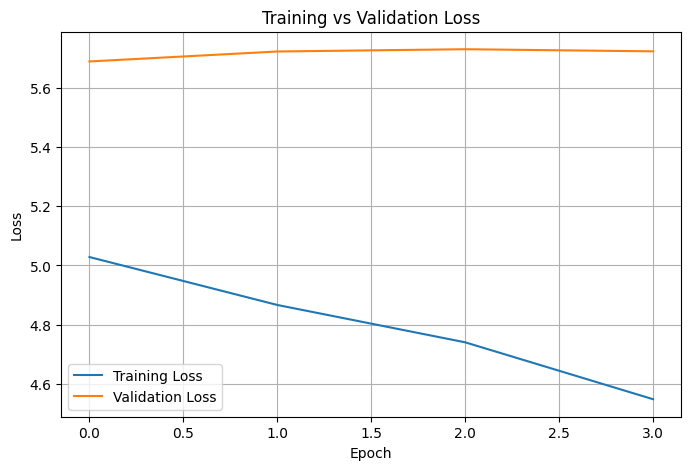

In [316]:
# ==========================================================
# TRAINING CURVES
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    validation_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.savefig(
    f"{DATASET_DIR}/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 8. Inference (Greedy + Beam Search)

> 8.1 Greedy Decoding

In [298]:
# ==========================================================
# GREEDY DECODING
# ==========================================================

def greedy_decode(model,
                  source_tensor,
                  max_length=MAX_LENGTH):

    model.eval()

    with torch.no_grad():

        # -------------------------
        # Encoder
        # -------------------------

        encoder_outputs, hidden, cell = model.encoder(source_tensor)

        # First input = <SOS>
        input_token = torch.tensor(
            [target_word2idx[SOS_TOKEN]],
            device=DEVICE
        )

        predicted_indices = []

        # -------------------------
        # Decoder Loop
        # -------------------------

        for _ in range(max_length):

            prediction, hidden, cell = model.decoder(
                input_token=input_token,
                hidden=hidden,
                cell=cell,
                encoder_outputs=encoder_outputs
            )

            # Prevent decoder from selecting <UNK>
            prediction[:, target_word2idx[UNK_TOKEN]] = -1e9

            predicted_token = prediction.argmax(dim=1).item()

            # Stop at <EOS>
            if predicted_token == target_word2idx[EOS_TOKEN]:
                break

            predicted_indices.append(predicted_token)

            input_token = torch.tensor(
                [predicted_token],
                device=DEVICE
            )

    return predicted_indices

> 8.2 Convert Token IDs → Sentence

In [299]:
# ==========================================================
# TOKEN IDS → SENTENCE
# ==========================================================

def indices_to_sentence(indices):

    words = []

    for idx in indices:

        word = target_idx2word[idx]

        if word in [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]:
            continue

        words.append(word)

    return " ".join(words)

> 8.3 Translate Sentence

In [300]:
# ==========================================================
# TRANSLATE SENTENCE
# ==========================================================

def translate_sentence(sentence):

    tokens = tokenize(sentence)

    indices = [
        source_word2idx.get(
            token,
            source_word2idx[UNK_TOKEN]
        )
        for token in tokens
    ]

    source_tensor = torch.tensor(
        indices,
        dtype=torch.long
    ).unsqueeze(0).to(DEVICE)

    predicted_indices = greedy_decode(
        model,
        source_tensor
    )

    translation = indices_to_sentence(
        predicted_indices
    )

    return translation

> 8.4 Verify Greedy Translation

In [301]:
# ==========================================================
# VERIFY GREEDY DECODING
# ==========================================================

sample = test_df.iloc[0]

print("Sanskrit:\n")
print(sample[SOURCE_COL])

print("\nReference:\n")
print(sample[TARGET_COL])

print("\nPrediction:\n")
print(translate_sentence(sample[SOURCE_COL]))

Sanskrit:

एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।

Reference:

Eclipse also helps the programmer to find out errors.

Prediction:

I have to add a value of the and the the to the


> 8.5 Beam Search

In [302]:
# ==========================================================
# BEAM SEARCH DECODING
# ==========================================================

def beam_search_decode(
    model,
    source_tensor,
    beam_width=BEAM_WIDTH,
    max_length=MAX_LENGTH
):

    model.eval()

    with torch.no_grad():

        # -------------------------
        # Encoder
        # -------------------------

        encoder_outputs, hidden, cell = model.encoder(source_tensor)

        beams = [
            (
                [target_word2idx[SOS_TOKEN]],
                0.0,
                hidden,
                cell
            )
        ]

        # -------------------------
        # Beam Loop
        # -------------------------

        for _ in range(max_length):

            candidates = []

            for sequence, score, hidden, cell in beams:

                last_token = sequence[-1]

                # Stop expanding completed sequences
                if last_token == target_word2idx[EOS_TOKEN]:

                    candidates.append(
                        (sequence, score, hidden, cell)
                    )

                    continue

                input_token = torch.tensor(
                    [last_token],
                    device=DEVICE
                )

                prediction, new_hidden, new_cell = model.decoder(
                    input_token=input_token,
                    hidden=hidden,
                    cell=cell,
                    encoder_outputs=encoder_outputs
                )

                # Prevent decoder from selecting <UNK>
                prediction[:, target_word2idx[UNK_TOKEN]] = -1e9

                log_probs = torch.log_softmax(
                    prediction,
                    dim=1
                )

                top_scores, top_indices = torch.topk(
                    log_probs,
                    beam_width
                )

                for i in range(beam_width):

                    next_sequence = sequence + [
                        top_indices[0, i].item()
                    ]

                    next_score = score + top_scores[0, i].item()

                    alpha = 0.7
                    beams = sorted(
                        candidates,
                        key=lambda x: x[1] / (len(x[0]) ** alpha),
                        reverse=True
                    )[:beam_width]

                    candidates.append(
                        (
                            next_sequence,
                            next_score,
                            new_hidden,
                            new_cell
                        )
                    )

            # Keep best beams
            beams = sorted(
                candidates,
                key=lambda x: x[1],
                reverse=True
            )[:beam_width]

            # Stop if all beams finished
            if all(
                beam[0][-1] == target_word2idx[EOS_TOKEN]
                for beam in beams
            ):
                break

        best_sequence = beams[0][0]

        # Remove <SOS>
        return best_sequence[1:]

> 8.6 Update translate_sentence()

In [303]:
# ==========================================================
# TRANSLATE SENTENCE
# ==========================================================

def translate_sentence(
    sentence,
    method="beam"
):

    tokens = tokenize(sentence)

    indices = [
        source_word2idx.get(
            token,
            source_word2idx[UNK_TOKEN]
        )
        for token in tokens
    ]

    source_tensor = torch.tensor(
        indices,
        dtype=torch.long
    ).unsqueeze(0).to(DEVICE)

    if method == "beam":

        predicted_indices = beam_search_decode(
            model,
            source_tensor
        )

    else:

        predicted_indices = greedy_decode(
            model,
            source_tensor
        )

    return indices_to_sentence(predicted_indices)

> 8.7 Verify Beam Search

In [304]:
# ==========================================================
# VERIFY BEAM SEARCH
# ==========================================================

sample = test_df.iloc[0]

print("Sanskrit:\n")
print(sample[SOURCE_COL])

print("\nReference:\n")
print(sample[TARGET_COL])

print("\nGreedy:\n")
print(
    translate_sentence(
        sample[SOURCE_COL],
        method="greedy"
    )
)

print("\nBeam:\n")
print(
    translate_sentence(
        sample[SOURCE_COL],
        method="beam"
    )
)

Sanskrit:

एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।

Reference:

Eclipse also helps the programmer to find out errors.

Greedy:

I have to add a value of the and the the to the

Beam:

I want to create a value of you want to create a bit


## 9. Evaluation

> 9.1 Generate Predictions

In [305]:
# ==========================================================
# GENERATE PREDICTIONS
# ==========================================================

references = []
predictions = []

for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df),
    desc="Generating Predictions"
):

    source_sentence = row[SOURCE_COL]
    target_sentence = row[TARGET_COL]

    predicted_sentence = translate_sentence(
        source_sentence,
        method="beam"
    )

    references.append(target_sentence)
    predictions.append(predicted_sentence)

print("Prediction generation completed.")

Generating Predictions:   0%|          | 0/1000 [00:00<?, ?it/s]

Prediction generation completed.


In [306]:
# ==========================================================
# SAMPLE PREDICTIONS
# ==========================================================

results_df = pd.DataFrame({
    "Sanskrit": test_df[SOURCE_COL],
    "Reference": references,
    "Prediction": predictions
})

results_df.head(10)

,Sanskrit,Reference,Prediction
0,एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि...,Eclipse also helps the programmer to find out ...,I want to create a value of you want to create...
1,विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्...,"""We having the same spirit of faith, according...","""And I I say unto you, that I am unto you, tha..."
2,"तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं...",Then it will automatically begin searching for...,I I will click on the and I will click on the
3,"सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्...",The iterator will be set to each of the indice...,It is the the to the the of the and the to the...
4,अपरं द्वितीयमुद्रायां तेन मोचितायां द्वितीयस्य...,"""And when he had opened the second seal, I hea...","""And I I the angel of the angel of the I am an..."
5,"वयम्, ओब्जेक्ट्स् स्वकीयान् स्थितीन् फील्ड्स् ...",We know that objects store their individual st...,"In this tutorial, we will learn how to create ..."
6,बाल: युष्मासु विश्वासं करोति ।,Boy has belief on you all.,Child has friendship on you all.
7,प्रकृति का अवलोकन करने से आप आश्चर्य चकित हो स...,Observing the nature helps create a sense of w...,It is also known in the body of the
8,यूयं कीदृक् तस्याज्ञा अपालयत भयकम्पाभ्यां तं ग...,"""And his inward affection is more abundant tow...","""And when ye unto you, That of the ye of the a..."
9,"""वर्षाया: जलस्य कश्चन अंश: भूमौ शुष्को भूत्वा ...",A part of rain water is absorbedby earth. Wate...,"""And when they had unto him, saying, of the an..."


> 9.2 BLEU Score

In [307]:
# ==========================================================
# BLEU SCORE
# ==========================================================

bleu_references = [
    [ref.split()]
    for ref in references
]

bleu_predictions = [
    pred.split()
    for pred in predictions
]

bleu_score = corpus_bleu(
    bleu_references,
    bleu_predictions
)

print(f"BLEU Score : {bleu_score:.4f}")

BLEU Score : 0.0380


> 9.3 BERTScore

In [308]:
# ==========================================================
# BERTSCORE
# ==========================================================

P, R, F1 = bert_score(
    predictions,
    references,
    lang="en",
    verbose=True
)

print(f"BERTScore (F1): {F1.mean().item():.4f}")

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


  0%|          | 0/30 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 9.77 seconds, 102.33 sentences/sec
BERTScore (F1): 0.8441


> 9.4 Inference Time

In [309]:
# ==========================================================
# INFERENCE TIME
# ==========================================================

start_time = time.time()

for sentence in test_df[SOURCE_COL]:

    translate_sentence(
        sentence,
        method="beam"
    )

end_time = time.time()

total_time = end_time - start_time

average_time = total_time / len(test_df)

print(f"Total Inference Time   : {total_time:.4f} seconds")
print(f"Average Time / Sentence: {average_time:.4f} seconds")

Total Inference Time   : 109.3001 seconds
Average Time / Sentence: 0.1093 seconds


> 9.5 Model Efficiency

In [310]:
# ==========================================================
# MODEL EFFICIENCY
# ==========================================================

print(f"Trainable Parameters : {count_parameters(model):,}")

Trainable Parameters : 16,698,337


> 9.6 Evaluation Summary

In [311]:
# ==========================================================
# EVALUATION SUMMARY
# ==========================================================

evaluation_df = pd.DataFrame({

    "Metric": [
        "BLEU Score",
        "BERTScore (F1)",
        "Inference Time (sec)",
        "Trainable Parameters"
    ],

    "Value": [

        round(bleu_score, 4),

        round(F1.mean().item(), 4),

        round(average_time, 4),

        count_parameters(model)
    ]

})

evaluation_df

,Metric,Value
0,BLEU Score,3.800000e-02
1,BERTScore (F1),8.441000e-01
2,Inference Time (sec),1.093000e-01
3,Trainable Parameters,1.669834e+07


## Section 10 — Generate submission.csv

> Generate Submission

In [312]:
# ==========================================================
# GENERATE SUBMISSION FILE
# ==========================================================

submission_df = pd.DataFrame()

submission_df["Sanskrit"] = test_df[SOURCE_COL]

submission_df["Prediction"] = predictions

submission_df.head()

,Sanskrit,Prediction
0,एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि...,I want to create a value of you want to create...
1,विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्...,"""And I I say unto you, that I am unto you, tha..."
2,"तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं...",I I will click on the and I will click on the
3,"सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्...",It is the the to the the of the and the to the...
4,अपरं द्वितीयमुद्रायां तेन मोचितायां द्वितीयस्य...,"""And I I the angel of the angel of the I am an..."


> Save CSV

In [313]:
# ==========================================================
# SAVE SUBMISSION
# ==========================================================

submission_path = f"{DATASET_DIR}/submission.csv"

submission_df.to_csv(
    submission_path,
    index=False,
    encoding="utf-8"
)

print(f"Submission saved at:\n{submission_path}")

Submission saved at:
/content/drive/MyDrive/NLU/content/submission.csv


> Verify

In [314]:
submission_df.sample(10)

,Sanskrit,Prediction
566,तर्जनी ‘J’ इत्यस्योपरि भवेत्।,"To do so, click on the"
429,"ड्राप्-डौन्-तः, अहं Author (A-Z) चिनोमि ।",I will select the the and I will select the
300,पुत्रेण पूपे याचिते तस्मै पाषाणं ददाति वा मत्स...,"""And when they had unto them that they should ..."
788,“ The age must be a positive integer.”,It is the the the of the and then it is the
613,सर्वेऽपि कुर्वन्तीति अहमपि इदं 800/600 चित्रकण...,It is based on the top of the on the top of th...
49,ऽन्यदेशीयलोका इस्रायेल्लोकाश्च सर्व्व एते सभाय...,"""And when they had unto the that they had been..."
721,"पश्यतां यत्, response.jsp सञ्चिका प्रोजेक्ट् व...",It is a file in the file file in the file file...
558,कथितमस्ति यत् जलस्य रस: सूर्ये स्थापितो वर्तते...,The is is is the the of the is of the
425,1. पोषणं कस्य अपरं नाम?,1. 1.
608,इमं पाठं पठित्वा भवान :,"""After studying this lesson, you will be able"
